In [44]:
import json
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd

# RESULTS_PATH = Path("/home/akapociu/ift/interactiondynamics/results/ds_sweep_results_6ep_3seed.jsonl")
SUMMARY_PATH = Path("/home/akapociu/ift/interactiondynamics/results/physics_sweep_summary.jsonl")

EXPECTED_SEEDS = 3

In [45]:
def safe_get(d: Dict[str, Any], *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


def extract_test_mrr(row):
    return safe_get(row, "best_snapshot", "test", "mrr", default=None)


def extract_walltime(row):
    return row.get("wall_sec", None)

def parse_run_string(run_name: str) -> Dict[str, Any]:
    """
    Example:
    Wikipedia_agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none
    or
    Wikipedia_agg=sum|update=tgn_gru|do=0.0|sdo=0.0|time=False
    """
    out = {
        "aggregator": None,
        "update": None,
        "dropout": None,
        "scorer_dropout": None,
        "time_features": None,
        "ift_kappa_param": None,
        "ift_dt": None,
        "ift_gamma": None,
        "ift_kappa_init": None,
        "ift_kappa_cap": None,
        "ift_kappa_max": None,
    }

    if run_name is None:
        return out

    if "__" in run_name:
        _, run_body = run_name.split("__", 1)
    else:
        run_body = run_name

    parts = run_body.split("|")
    for part in parts:
        if "=" in part:
            k, v = part.split("=", 1)

            if k.endswith("agg"):
                out["aggregator"] = v
            elif k == "update":
                out["update"] = v
            elif k == "do":
                out["dropout"] = float(v)
            elif k == "sdo":
                out["scorer_dropout"] = float(v)
            elif k == "time":
                out["time_features"] = (v == "True")
            elif k == "dt":
                out["ift_dt"] = float(v)
            elif k == "gamma":
                out["ift_gamma"] = float(v)
            elif k == "k0":
                out["ift_kappa_init"] = float(v)
            elif k == "cap":
                if v == "none":
                    out["ift_kappa_cap"] = False
                    out["ift_kappa_max"] = None
                else:
                    out["ift_kappa_cap"] = True
                    try:
                        out["ift_kappa_max"] = float(v)
                    except ValueError:
                        out["ift_kappa_max"] = v
        else:
            if part in {"softplus", "exp"}:
                out["ift_kappa_param"] = part

    return out

In [46]:
def load_summary_jsonl(path: Path) -> pd.DataFrame:
    rows = []

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            row = json.loads(line)

            dataset = row.get("dataset", None)
            run_name = row.get("name", row.get("run", None))
            seed = row.get("seed", None)
            best_val_mrr = row.get("best_val_mrr", None)
            best_epoch = row.get("best_epoch", None)
            test_mrr = extract_test_mrr(row)
            wall_sec = extract_walltime(row)

            parsed = parse_run_string(run_name)

            clean = {
                "dataset": dataset,
                "run_name": run_name,
                "seed": seed,
                "best_val_mrr": best_val_mrr,
                "best_test_mrr": test_mrr,
                "wall_sec": wall_sec,
                "best_epoch": best_epoch,

                # best snapshot metrics
                "best_val_early_mrr": safe_get(row, "best_snapshot", "val", "early_mrr", default=None),
                "best_val_late_mrr": safe_get(row, "best_snapshot", "val", "late_mrr", default=None),
                "best_test_early_mrr": safe_get(row, "best_snapshot", "test", "early_mrr", default=None),
                "best_test_late_mrr": safe_get(row, "best_snapshot", "test", "late_mrr", default=None),

                # final snapshot metrics
                "final_val_mrr": safe_get(row, "final_snapshot", "val", "mrr", default=None),
                "final_test_mrr": safe_get(row, "final_snapshot", "test", "mrr", default=None),
                "final_val_early_mrr": safe_get(row, "final_snapshot", "val", "early_mrr", default=None),
                "final_val_late_mrr": safe_get(row, "final_snapshot", "val", "late_mrr", default=None),
                "final_test_early_mrr": safe_get(row, "final_snapshot", "test", "early_mrr", default=None),
                "final_test_late_mrr": safe_get(row, "final_snapshot", "test", "late_mrr", default=None),

                **parsed,
            }
            rows.append(clean)

    return pd.DataFrame(rows)


summary_df = load_summary_jsonl(SUMMARY_PATH)
summary_df["overfit_gap"] = summary_df["best_test_mrr"] - summary_df["final_test_mrr"]
summary_df["peaked_early"] = summary_df["best_epoch"] <= 2
summary_df["completed_run"] = summary_df["final_test_mrr"].notna()
summary_df.shape

(585, 31)

In [52]:
spring_ring_df = summary_df[summary_df["dataset"] == "spring_ring"].copy()
spring_mass_df = summary_df[summary_df["dataset"] == "spring_mass"].copy()
wave_df        = summary_df[summary_df["dataset"] == "wave"].copy()
three_body_df  = summary_df[summary_df["dataset"] == "threebody"].copy()
charged_df     = summary_df[summary_df["dataset"] == "nbody"].copy()
stachyose_df   = summary_df[summary_df["dataset"] == "stachyose"].copy()

dataset_dfs = {
    "spring_ring": spring_ring_df,
    "spring_mass": spring_mass_df,
    "wave": wave_df,
    "threebody": three_body_df,
    "nbody": charged_df,
    "stachyose": stachyose_df,
}

for name, df in dataset_dfs.items():
    print(name, df.shape)

spring_ring (72, 31)
spring_mass (72, 31)
wave (75, 31)
threebody (72, 31)
nbody (75, 31)
stachyose (75, 31)


In [53]:
def build_dataset_model_ranking(df: pd.DataFrame, expected_seeds: int = 3) -> pd.DataFrame:
    out = (
        df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              avg_val_mrr=("best_val_mrr", "mean"),
              std_val_mrr=("best_val_mrr", "std"),
              mean_test_mrr=("best_test_mrr", "mean"),
              std_test_mrr=("best_test_mrr", "std"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
              wall_sec_std=("wall_sec", "std"),
          )
          .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [56]:
rank_all_by_dataset = {
    ds: build_dataset_model_ranking(df, expected_seeds=EXPECTED_SEEDS)
    for ds, df in dataset_dfs.items()
}

spring_mass_rank_all = rank_all_by_dataset["spring_mass"]
spring_ring_rank_all = rank_all_by_dataset["spring_ring"]
wave_rank_all   = rank_all_by_dataset["wave"]
nbody_rank_all = rank_all_by_dataset["nbody"]
stachyose_rank_all = rank_all_by_dataset["stachyose"]
threebody_rank_all = rank_all_by_dataset["threebody"]

In [57]:
def build_filtered_ranking(
    df: pd.DataFrame,
    expected_seeds: int = 3,
    only_ift_aggregator: bool = False,
    only_ift_update: bool = False,
    only_ift_both: bool = False,
) -> pd.DataFrame:

    sub = df.copy()

    if only_ift_both:
        sub = sub[(sub["aggregator"] == "ift") & (sub["update"] == "ift_update")]
    elif only_ift_aggregator:
        sub = sub[sub["aggregator"] == "ift"]
    elif only_ift_update:
        sub = sub[sub["update"] == "ift_update"]

    out = (
        sub.groupby(["dataset", "aggregator", "update"], dropna=False)
           .agg(
                n_seeds=("seed", "nunique"),
                avg_val_mrr=("best_val_mrr", "mean"),
                std_val_mrr=("best_val_mrr", "std"),
                mean_test_mrr=("best_test_mrr", "mean"),
                std_test_mrr=("best_test_mrr", "std"),
                mean_overfit_gap=("overfit_gap", "mean"),
                peaked_early_rate=("peaked_early", "mean"),

                avg_early_val_mrr=("best_val_early_mrr", "mean"),
                avg_late_val_mrr=("best_val_late_mrr", "mean"),
                avg_early_test_mrr=("best_test_early_mrr", "mean"),
                avg_late_test_mrr=("best_test_late_mrr", "mean"),

                walltime_mean_sec=("wall_sec", "mean"),
                walltime_std_sec=("wall_sec", "std"),
            )
           .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [60]:
ift_tables_by_dataset = {}

for ds, full_table in rank_all_by_dataset.items():
    ift_tables_by_dataset[ds] = {
        "ift_aggregator_only": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] != "ift_update")
        ].copy(),

        "ift_update_only": full_table[
            (full_table["update"] == "ift_update") &
            (full_table["aggregator"] != "ift")
        ].copy(),

        "ift_both": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] == "ift_update")
        ].copy(),
    }

for ds in [
    "spring_mass",
    "spring_ring",
    "wave",
    "nbody",
    "stachyose",
    "threebody",
    ]:
    print(f"\n===== {ds}: IFT aggregator only =====")
    display(ift_tables_by_dataset[ds]["ift_aggregator_only"])

    print(f"\n===== {ds}: IFT update only =====")
    display(ift_tables_by_dataset[ds]["ift_update_only"])

    print(f"\n===== {ds}: IFT aggregator + IFT update =====")
    display(ift_tables_by_dataset[ds]["ift_both"])


===== spring_mass: IFT aggregator only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,spring_mass,ift,tgn_gru,1,0.918790,0.021072,0.934293,0.013065,0.008707,0.666667,0.803094,0.927758,0.837662,0.941670,45.981799,0.066170,3,True
1,spring_mass,ift,hopfield_update,2,0.911468,0.012868,0.930976,0.001678,-0.002916,0.333333,0.697446,0.928059,0.738208,0.945691,65.728694,0.094582,3,True
19,spring_mass,ift,hnn,20,0.295148,0.018618,0.448398,0.021270,0.032116,0.666667,0.238650,0.299528,0.303847,0.459432,96.107561,0.049860,3,True
22,spring_mass,ift,lnn,23,0.257673,0.059353,0.318752,0.028806,0.045682,1.000000,0.294143,0.254846,0.382018,0.313922,75.855733,0.062768,3,True



===== spring_mass: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
11,spring_mass,deepsets,ift_update,12,0.398682,0.009478,0.434235,0.002303,0.005337,0.333333,0.604116,0.382757,0.808633,0.405655,55.332139,0.063680,3,True
12,spring_mass,settransformer,ift_update,13,0.398197,0.018920,0.431002,0.003420,0.000000,0.000000,0.788348,0.367953,0.844388,0.399446,89.598932,0.036059,3,True
15,spring_mass,sum,ift_update,16,0.372248,0.005246,0.476710,0.024059,0.076245,1.000000,0.456515,0.365716,0.596121,0.467595,46.269647,0.038413,3,True



===== spring_mass: IFT aggregator + IFT update =====


...

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
9,threebody,ift,hopfield_update,10,0.853244,0.035157,0.601189,0.113949,-0.050354,0.666667,0.814858,0.855948,0.560270,0.604030,70.425577,0.049378,3,True
10,threebody,ift,tgn_gru,11,0.742664,0.126865,0.567749,0.056289,0.058330,1.000000,0.707300,0.745155,0.544856,0.569338,49.231504,0.053100,3,True
16,threebody,ift,hnn,17,0.406289,0.022226,0.380115,0.011709,-0.006237,0.666667,0.474101,0.401514,0.358819,0.381594,103.100532,0.649551,3,True
19,threebody,ift,lnn,20,0.394421,0.003266,0.387936,0.007980,0.003223,1.000000,0.418060,0.392756,0.367035,0.389387,81.545041,0.096271,3,True



===== threebody: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
2,threebody,deepsets,ift_update,3,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,59.138585,0.091610,3,True
8,threebody,settransformer,ift_update,9,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,96.319167,0.089119,3,True
23,threebody,sum,ift_update,24,0.364779,0.061164,0.407012,0.02688,0.004345,0.666667,0.433107,0.359968,0.430197,0.405402,49.350729,0.023386,3,True



===== threebody: IFT aggregator + IFT update =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
11,threebody,ift,ift_update,12,0.628955,0.043248,0.551247,0.117862,-0.022982,0.333333,0.783146,0.618096,0.698179,0.541044,61.29694,0.05691,3,True


In [ ]:
big_rank_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
              .agg(
                    n_seeds=("seed", "nunique"),
                    avg_val_mrr=("best_val_mrr", "mean"),
                    std_val_mrr=("best_val_mrr", "std"),
                    mean_test_mrr=("best_test_mrr", "mean"),
                    std_test_mrr=("best_test_mrr", "std"),
                    mean_overfit_gap=("overfit_gap", "mean"),
                    peaked_early_rate=("peaked_early", "mean"),
                    avg_early_val_mrr=("best_val_early_mrr", "mean"),
                    avg_late_val_mrr=("best_val_late_mrr", "mean"),
                    avg_early_test_mrr=("best_test_early_mrr", "mean"),
                    avg_late_test_mrr=("best_test_late_mrr", "mean"),
                    wall_sec_mean=("wall_sec", "mean"),
                    wall_sec_std=("wall_sec", "std"),
              )
              .reset_index()
)

big_rank_table["did_complete"] = big_rank_table["n_seeds"] == EXPECTED_SEEDS

big_rank_table = big_rank_table.sort_values(
    by=["avg_val_mrr", "mean_test_mrr"],
    ascending=[False, False]
).reset_index(drop=True)

big_rank_table["global_rank"] = np.arange(1, len(big_rank_table) + 1)

big_rank_table = big_rank_table[
    [
        "dataset",
        "aggregator",
        "update",
        # "rank_in_dataset",
        "avg_val_mrr",
        "std_val_mrr",
        "mean_test_mrr",
        "std_test_mrr",
        "mean_overfit_gap",
        "peaked_early_rate",
        "avg_early_val_mrr",
        "avg_late_val_mrr",
        "avg_early_test_mrr",
        "avg_late_test_mrr",
        "wall_sec_mean",
        "wall_sec_std",
        "n_seeds",
        "did_complete",
    ]
]

display(big_rank_table.head(10))

,dataset,aggregator,update,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,threebody,deepsets,hnn,1.0,0.0,1.0,0.0,0.01184,1.0,1.0,1.0,1.0,1.0,91.451567,0.101951,3,True
1,threebody,deepsets,hopfield_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,69.621379,0.045268,3,True
2,threebody,deepsets,ift_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,59.138585,0.091610,3,True
3,threebody,deepsets,tgn_gru,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,48.413865,0.058702,3,True
4,threebody,hopfield,hnn,1.0,0.0,1.0,0.0,0.10348,1.0,1.0,1.0,1.0,1.0,113.873290,0.065771,3,True
5,threebody,hopfield,hopfield_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,80.679105,0.031588,3,True
6,threebody,hopfield,tgn_gru,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,60.339083,0.016226,3,True
7,threebody,settransformer,hopfield_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,105.897764,0.096286,3,True
8,threebody,settransformer,ift_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,96.319167,0.089119,3,True
9,uracil,deepsets,hopfield_update,1.0,0.0,1.0,0.0,0.00000,1.0,1.0,1.0,1.0,1.0,92.115183,0.027926,3,True


In [ ]:
combo_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              mean_best_val_mrr=("best_val_mrr", "mean"),
              mean_best_test_mrr=("best_test_mrr", "mean"),
              completion_rate=("completed_run", "mean"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
          )
          .reset_index()
)

display(combo_table)

,dataset,aggregator,update,n_seeds,mean_best_val_mrr,mean_best_test_mrr,completion_rate,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean
0,naphthalene,deepsets,hnn,3,0.211513,0.212347,1.0,0.001225,0.666667,0.214357,0.211453,0.212461,0.212345,293.728247
1,naphthalene,deepsets,hopfield_update,3,0.754116,0.753662,1.0,0.000000,0.666667,0.755332,0.754090,0.754562,0.753643,226.282571
2,naphthalene,deepsets,ift_update,3,1.000000,1.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,192.603687
3,naphthalene,deepsets,lnn,3,0.212927,0.212664,1.0,0.017484,0.666667,0.197690,0.213246,0.197655,0.212978,229.481864
4,naphthalene,deepsets,tgn_gru,3,0.230105,0.229005,1.0,0.036051,1.000000,0.192866,0.230884,0.188967,0.229841,157.856882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,wave,sum,hnn,3,0.192107,0.174819,1.0,-0.000178,0.333333,0.187769,0.197530,0.165678,0.184976,10.377528
191,wave,sum,hopfield_update,3,0.201539,0.197563,1.0,-0.005191,1.000000,0.209324,0.191809,0.209200,0.184632,7.517752
192,wave,sum,ift_update,3,0.207588,0.196200,1.0,-0.001288,0.333333,0.207710,0.207434,0.209030,0.181945,6.208733
193,wave,sum,lnn,3,0.191425,0.192834,1.0,0.004025,1.000000,0.190194,0.192963,0.174368,0.213352,8.077340


In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = Path("/home/akapociu/ift/interactiondynamics/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = [
    "spring_mass",
    "spring_ring",
    "wave",
    "nbody",
    "stachyose",
    "threebody",
]

plot_df = pd.concat(
    [rank_all_by_dataset[ds].copy() for ds in DATASET_ORDER],
    ignore_index=True
)

plot_df["model_combo"] = plot_df["aggregator"] + " + " + plot_df["update"]

# normalize runtime column name if needed
if "wall_sec_mean" not in plot_df.columns and "walltime_mean_sec" in plot_df.columns:
    plot_df["wall_sec_mean"] = plot_df["walltime_mean_sec"]

if "wall_sec_std" not in plot_df.columns and "walltime_std_sec" in plot_df.columns:
    plot_df["wall_sec_std"] = plot_df["walltime_std_sec"]

plot_df.head()

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete,model_combo
0,spring_mass,ift,tgn_gru,1,0.918790,0.021072,0.934293,0.013065,0.008707,0.666667,0.803094,0.927758,0.837662,0.941670,45.981799,0.066170,3,True,ift + tgn_gru
1,spring_mass,ift,hopfield_update,2,0.911468,0.012868,0.930976,0.001678,-0.002916,0.333333,0.697446,0.928059,0.738208,0.945691,65.728694,0.094582,3,True,ift + hopfield_update
2,spring_mass,ift,ift_update,3,0.872585,0.013956,0.899184,0.005645,-0.002213,0.333333,0.779097,0.879832,0.820966,0.905155,57.159437,0.066858,3,True,ift + ift_update
3,spring_mass,hopfield,hopfield_update,4,0.817927,0.001629,0.881276,0.010521,0.006530,0.333333,0.548066,0.838846,0.721507,0.893472,75.195814,0.139033,3,True,hopfield + hopfield_update
4,spring_mass,sum,hopfield_update,5,0.817863,0.073377,0.873729,0.038855,0.001556,0.666667,0.589473,0.835568,0.693022,0.887524,56.061294,0.029786,3,True,sum + hopfield_update


KeyError: 'spring_ring_2d'

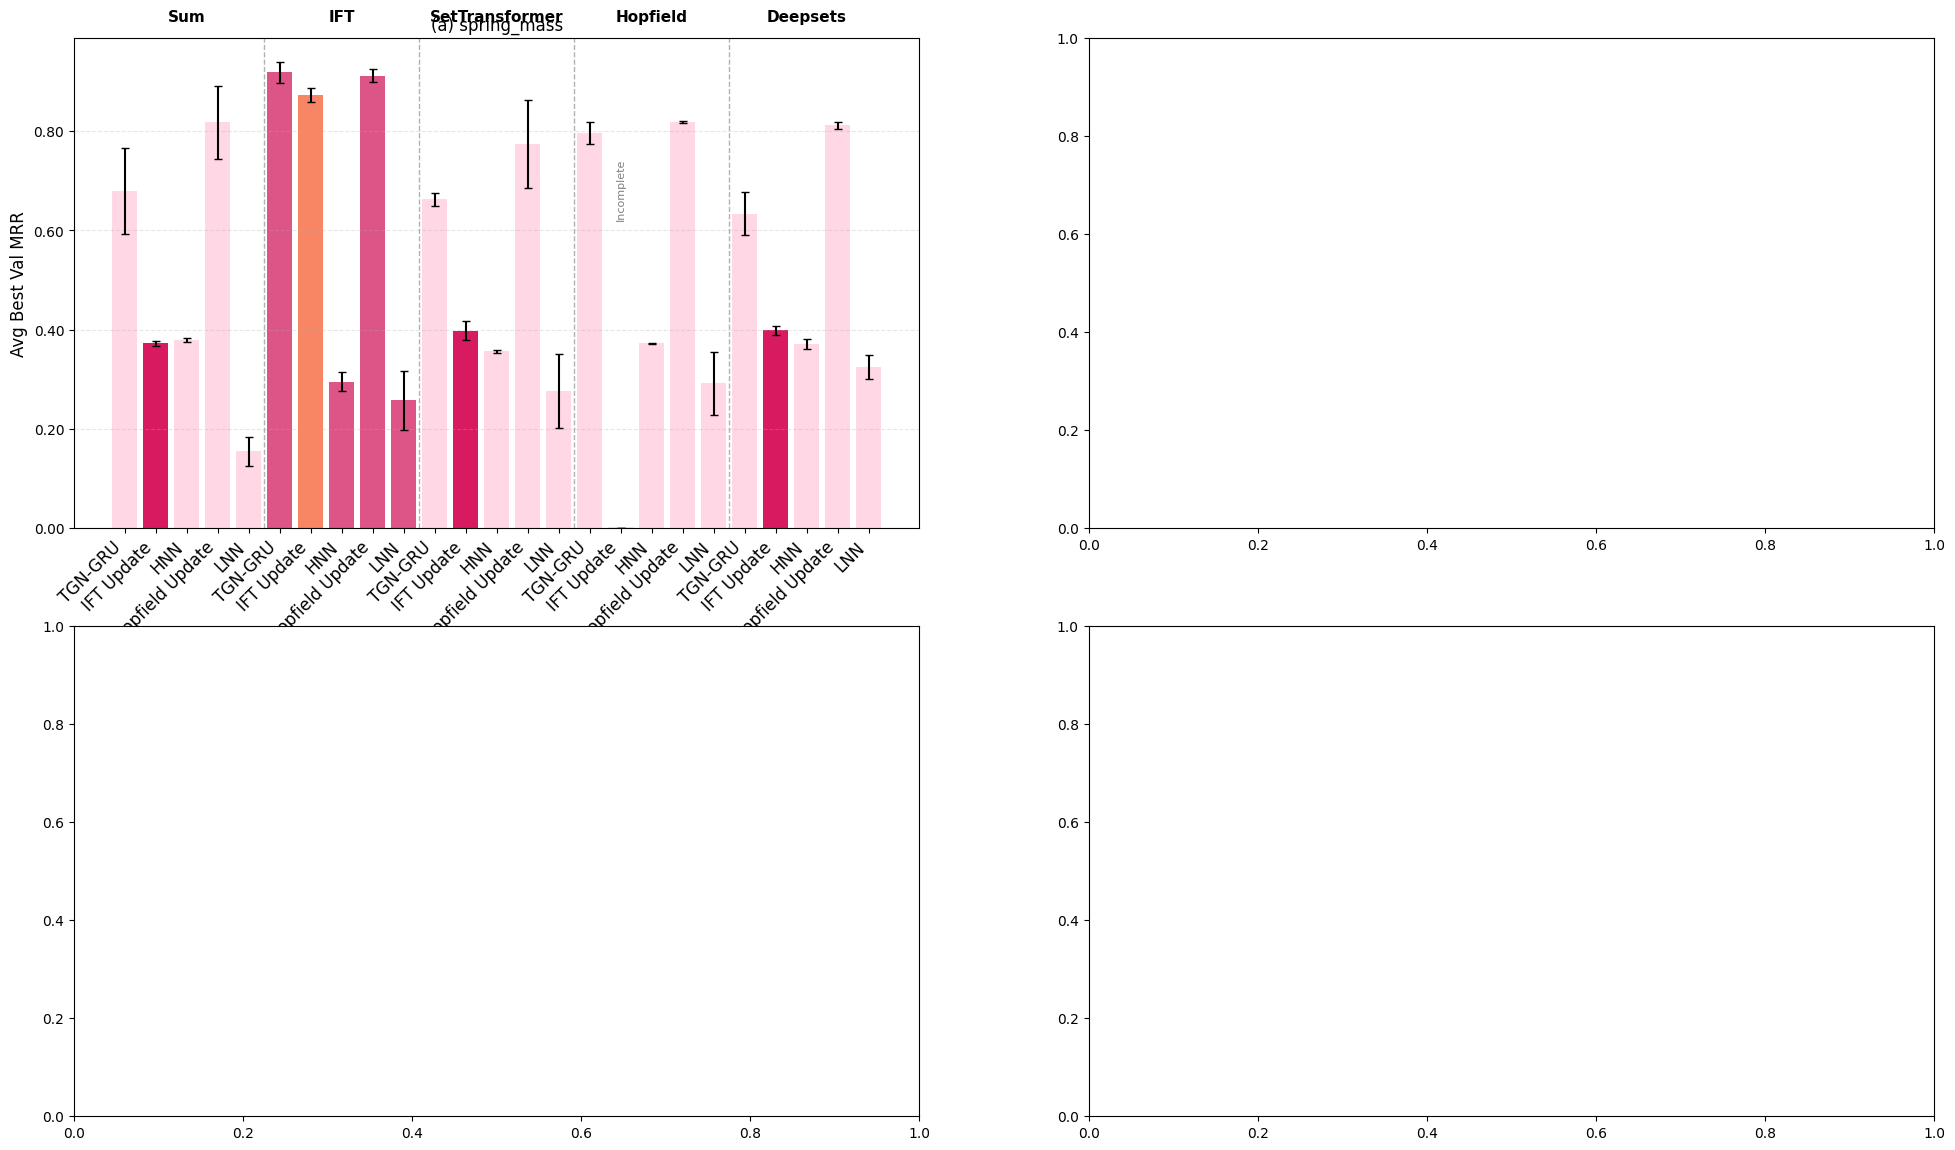

In [ ]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(2, 2, figsize=(24, 14), sharey=False)
axes = axes.flatten()

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

    upd_map = {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }
    return f"{agg_map.get(agg, agg)} / {upd_map.get(upd, upd)}"

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full expected combo grid
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge actual results onto full combo list
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    # preserve explicit ordering
    df_full["aggregator"] = pd.Categorical(df_full["aggregator"], categories=AGG_ORDER, ordered=True)
    df_full["update"] = pd.Categorical(df_full["update"], categories=UPD_ORDER, ordered=True)
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["avg_val_mrr"].values
    err = df_full["std_val_mrr"].fillna(0).values
    labels = [pretty_upd(u) for u in df_full["update"]]

    # missing bars should still occupy space
    bar_heights = np.nan_to_num(y, nan=0.0)

    bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

    for i, (bar, upd, agg, val) in enumerate(zip(bars, df_full["update"], df_full["aggregator"], y)):
        if pd.isna(val):
            # incomplete combo
            bar.set_facecolor("#f2f2f2")
            bar.set_edgecolor("gray")
            bar.set_hatch("//")
            bar.set_linewidth(1.0)

            # mark incomplete above baseline
            ax.text(
                i, 0.62 if ds in ["spring_mass", "spring_ring_2d", "wave", "charged_particles_binned", "md22_binned","three_body_binned"] else 0.03,
                "Incomplete",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )
        else:
            if (upd == "ift_update") and (agg == "ift"):
                bar.set_facecolor("#f88664")
            elif upd == "ift_update":
                bar.set_facecolor("#d81b60")
            elif agg == "ift":
                bar.set_facecolor("#dd5486")
            else:
                bar.set_facecolor("#ffd7e5")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # optional group labels centered over each block of 5
    group_centers = [2, 7, 12, 17, 22]
    group_names = ["Sum", "IFT", "SetTransformer", "Hopfield", "Deepsets"]
    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            1.015 if ds in ["spring_mass", "spring_ring", "wave", "nbody", "threebody", "naphthalene",] else 1.04,
            gname,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Avg Best Val MRR", fontsize=12)
    ax.set_xlabel("Update (grouped by Aggregator)", fontsize=12, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    if ds in ["Wikipedia", "Reddit", "MOOC"]:
        ax.set_ylim(0.6, 1.05)
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.1)

legend_elements = [
    Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Average Best Validation MRR", fontsize=20)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.subplots_adjust(
    hspace=0.5,   # vertical spacing between rows
    wspace=0.08    # horizontal spacing between columns
)
fig, axes = plt.subplots(2, 2, figsize=(24, 18), sharey=False)
fig.savefig(PLOTS_DIR / "grouped_by_aggregator_bar_with_incomplete.png", dpi=300, bbox_inches="tight")
plt.show()


=== spring_mass ===
        aggregator           update  avg_val_mrr
0              ift          tgn_gru     0.918790
1              ift  hopfield_update     0.911468
2              ift       ift_update     0.872585
3         hopfield  hopfield_update     0.817927
4              sum  hopfield_update     0.817863
5         deepsets  hopfield_update     0.811282
6         hopfield          tgn_gru     0.795617
7   settransformer  hopfield_update     0.774641
8              sum          tgn_gru     0.679200
9   settransformer          tgn_gru     0.662611
10        deepsets          tgn_gru     0.633218
11        deepsets       ift_update     0.398682
12  settransformer       ift_update     0.398197
13             sum              hnn     0.379452
14        hopfield              hnn     0.372699
15             sum       ift_update     0.372248
16        deepsets              hnn     0.371354
17  settransformer              hnn     0.356096
18        deepsets              lnn     0.325426

/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/2509535687.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation sin

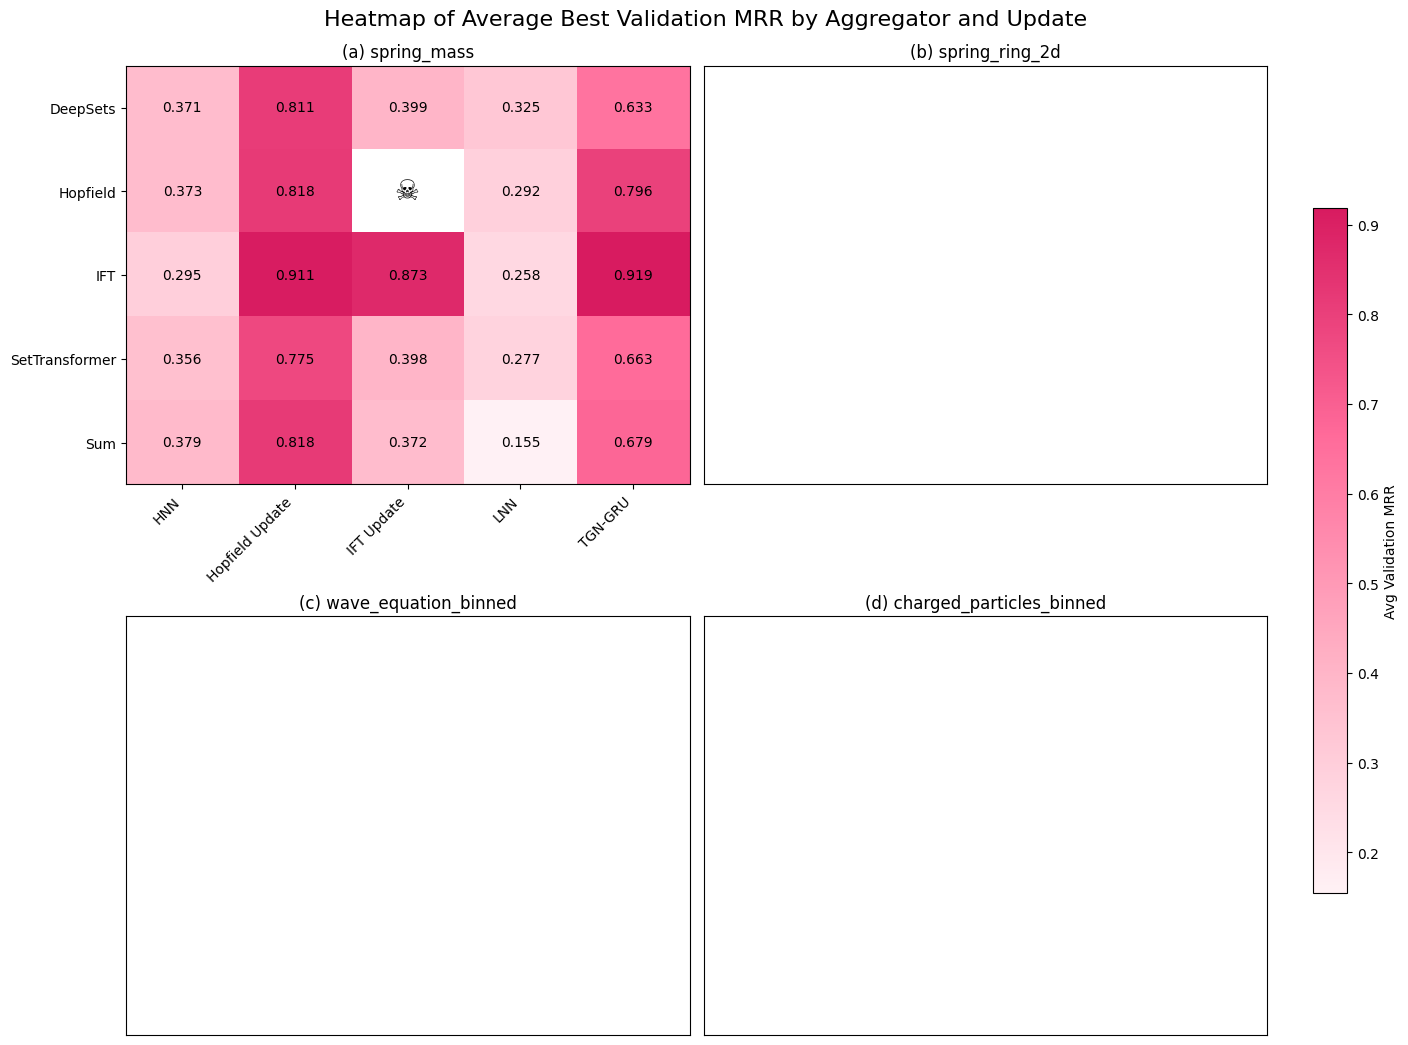

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# custom pink colormap
pink_cmap = LinearSegmentedColormap.from_list(
    "pinkmap",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

global_vmin = plot_df["avg_val_mrr"].min()
global_vmax = plot_df["avg_val_mrr"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="avg_val_mrr"
    )
    print(f"\n=== {ds} ===")
    print(df[["aggregator", "update", "avg_val_mrr"]])
    print("heat shape:", heat.shape)
    print(heat)
    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=pink_cmap
    )

    ax.set_title(f"{label} {ds}")

    # prettier labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)
    # annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if pd.notna(val):
                text = f"{val:.3f}"
                color = "black"
                size = 10
            else:
                text = "☠️"
                size = 20

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )
                

# put colorbar on the right side of the figure
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Avg Validation MRR")

fig.suptitle("Heatmap of Average Best Validation MRR by Aggregator and Update", fontsize=16, y=1.03)
fig.savefig(
    PLOTS_DIR / "heatmap_avg_val_mrr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3809362158.py:51: UserWarning: Attempting to set identical low and high ylims makes transformation sin

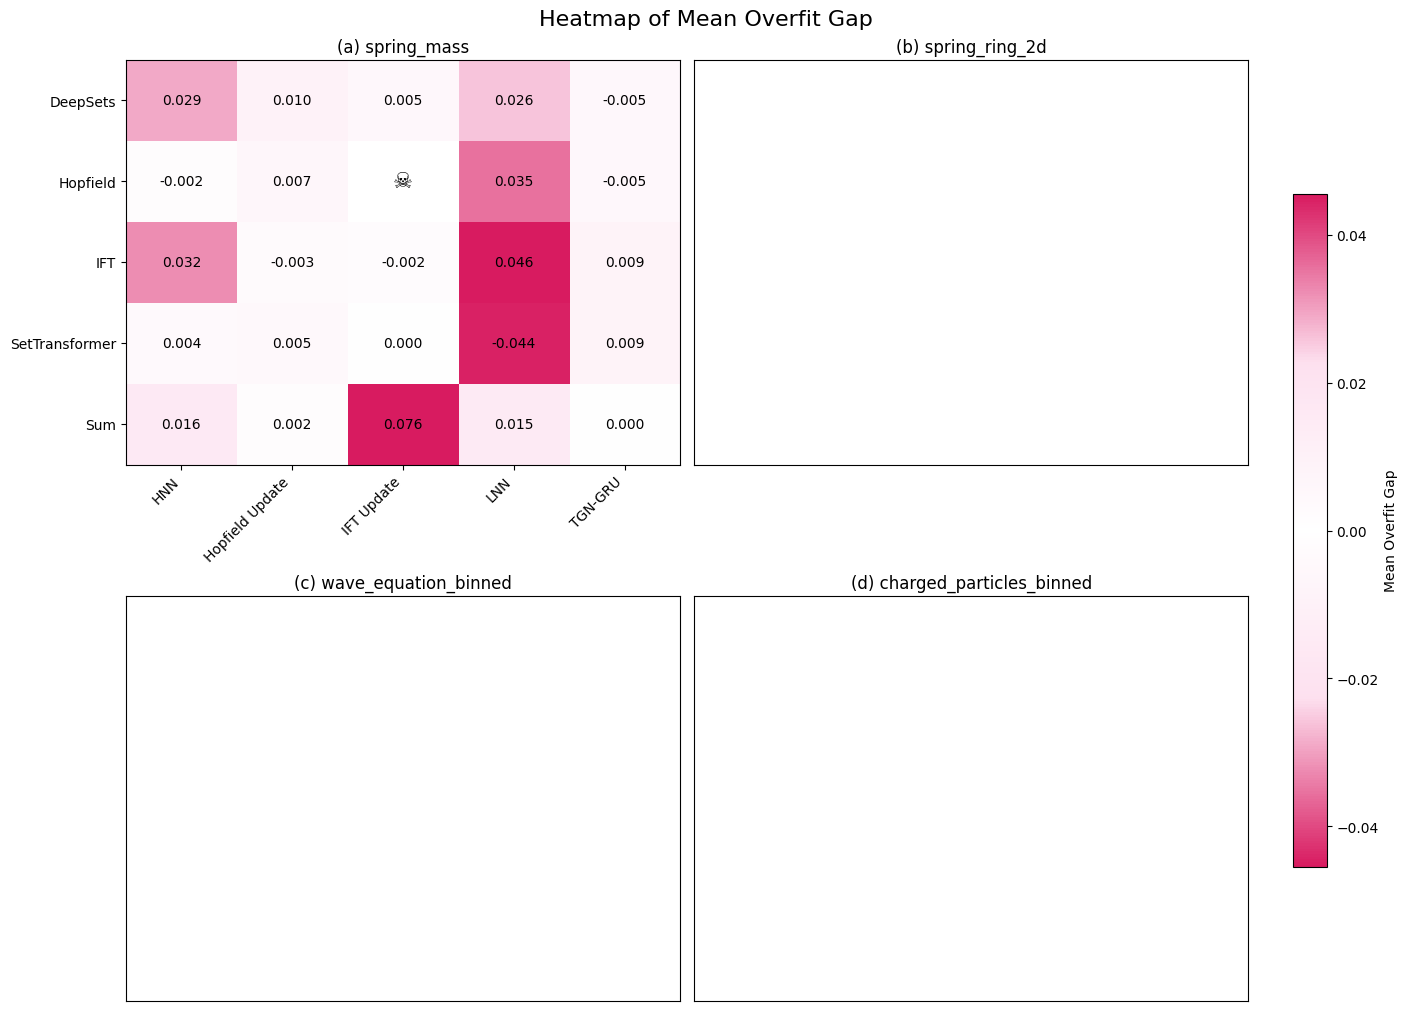

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# 🔹 pretty names (same as before)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 🔥 diverging pink colormap (negative → light, positive → dark)
diverging_pink = LinearSegmentedColormap.from_list(
    "diverging_pink",
    ["#d81b60", "#fde0ef", "#ffffff", "#fde0ef", "#d81b60"]  # light pink → white → dark pink
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 symmetric scale around 0
absmax = np.nanpercentile(
    np.abs(plot_df["mean_overfit_gap"].values),
    95   # or 90 if you want stronger clipping
)
global_vmin = -absmax
global_vmax = absmax

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="mean_overfit_gap"
    )

    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=diverging_pink
    )

    ax.set_title(f"{label} {ds}")

    # ✅ same pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val:.3f}"

                # white text on darker cells
                color = "black"
                size = 10
            else:
                text = "☠️"
                color = "black"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )

# 🔹 clean colorbar (RIGHT SIDE, same as before)
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Mean Overfit Gap")

fig.suptitle(
    "Heatmap of Mean Overfit Gap",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_mean_overfit_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_2952914/3918472262.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation sin

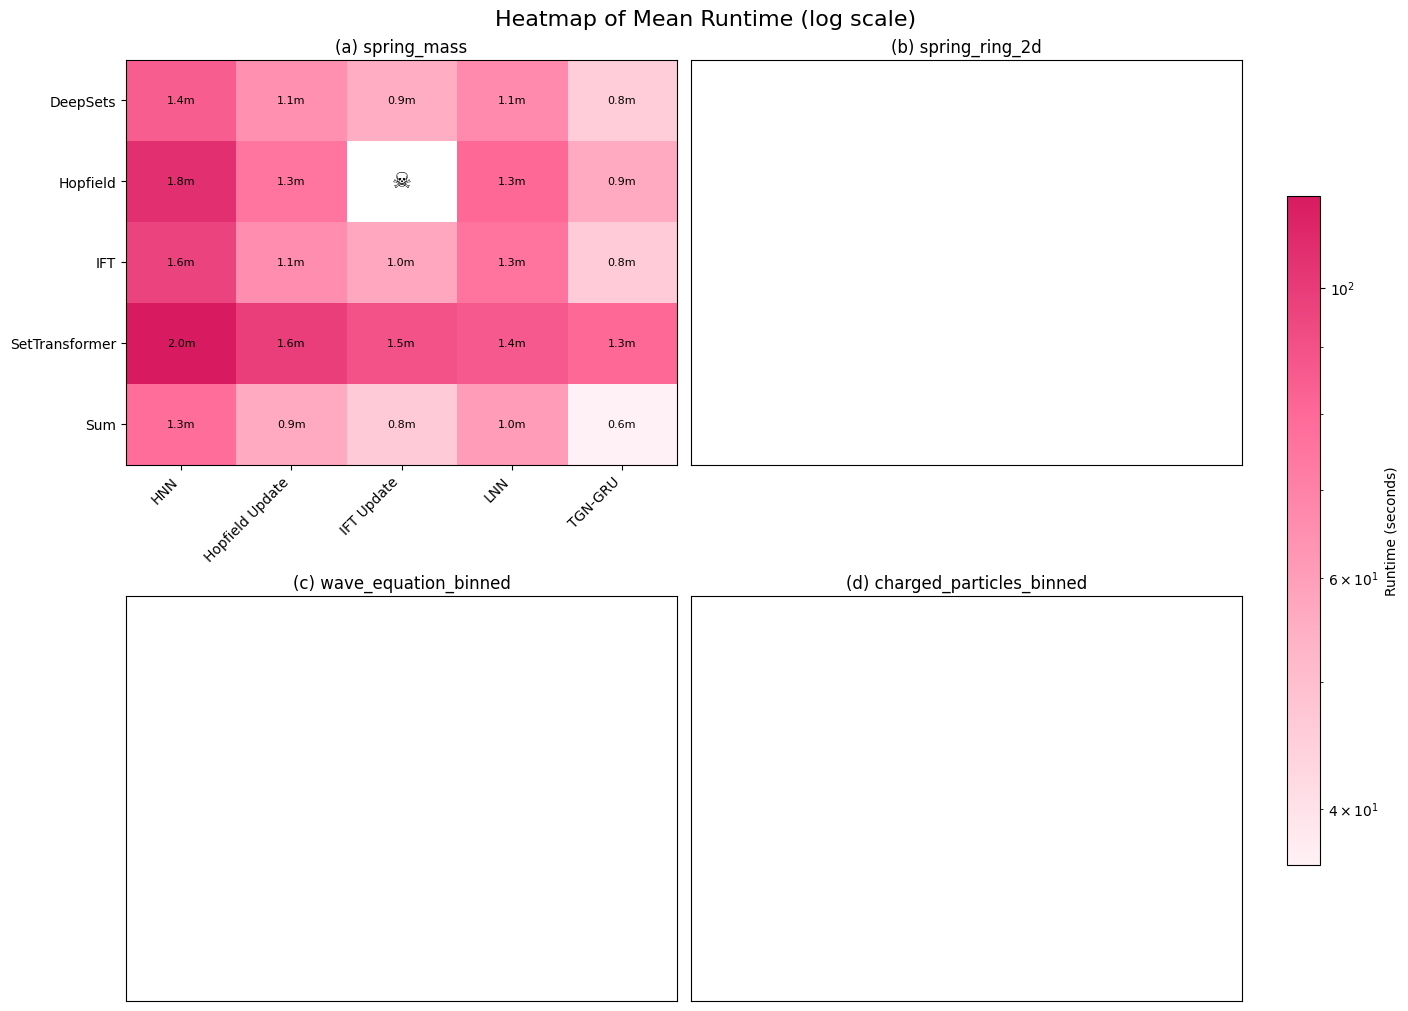

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors

# 🔹 pretty names (reuse)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 💖 sequential pink colormap (low → high runtime)
pink_cmap = LinearSegmentedColormap.from_list(
    "pink_runtime",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 global scale (keeps comparison fair)
global_vmin = plot_df["wall_sec_mean"].min()
global_vmax = plot_df["wall_sec_mean"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    df = rank_all_by_dataset[ds].copy()

    heat = df.pivot(
        index="aggregator",
        columns="update",
        values="wall_sec_mean"
    )

    im = ax.imshow(
        heat.values,
        norm=colors.LogNorm(vmin=global_vmin, vmax=global_vmax),
        cmap=pink_cmap,
        aspect="auto"
    )

    ax.set_title(f"{label} {ds}")

    # ✅ consistent pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate (minutes, black text only)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val/60:.1f}m"   # convert sec → minutes
                size = 8
            else:
                text = "☠️"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color="black"
            )

# 🔹 clean right-side colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Runtime (seconds)")

fig.suptitle(
    "Heatmap of Mean Runtime (log scale)",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

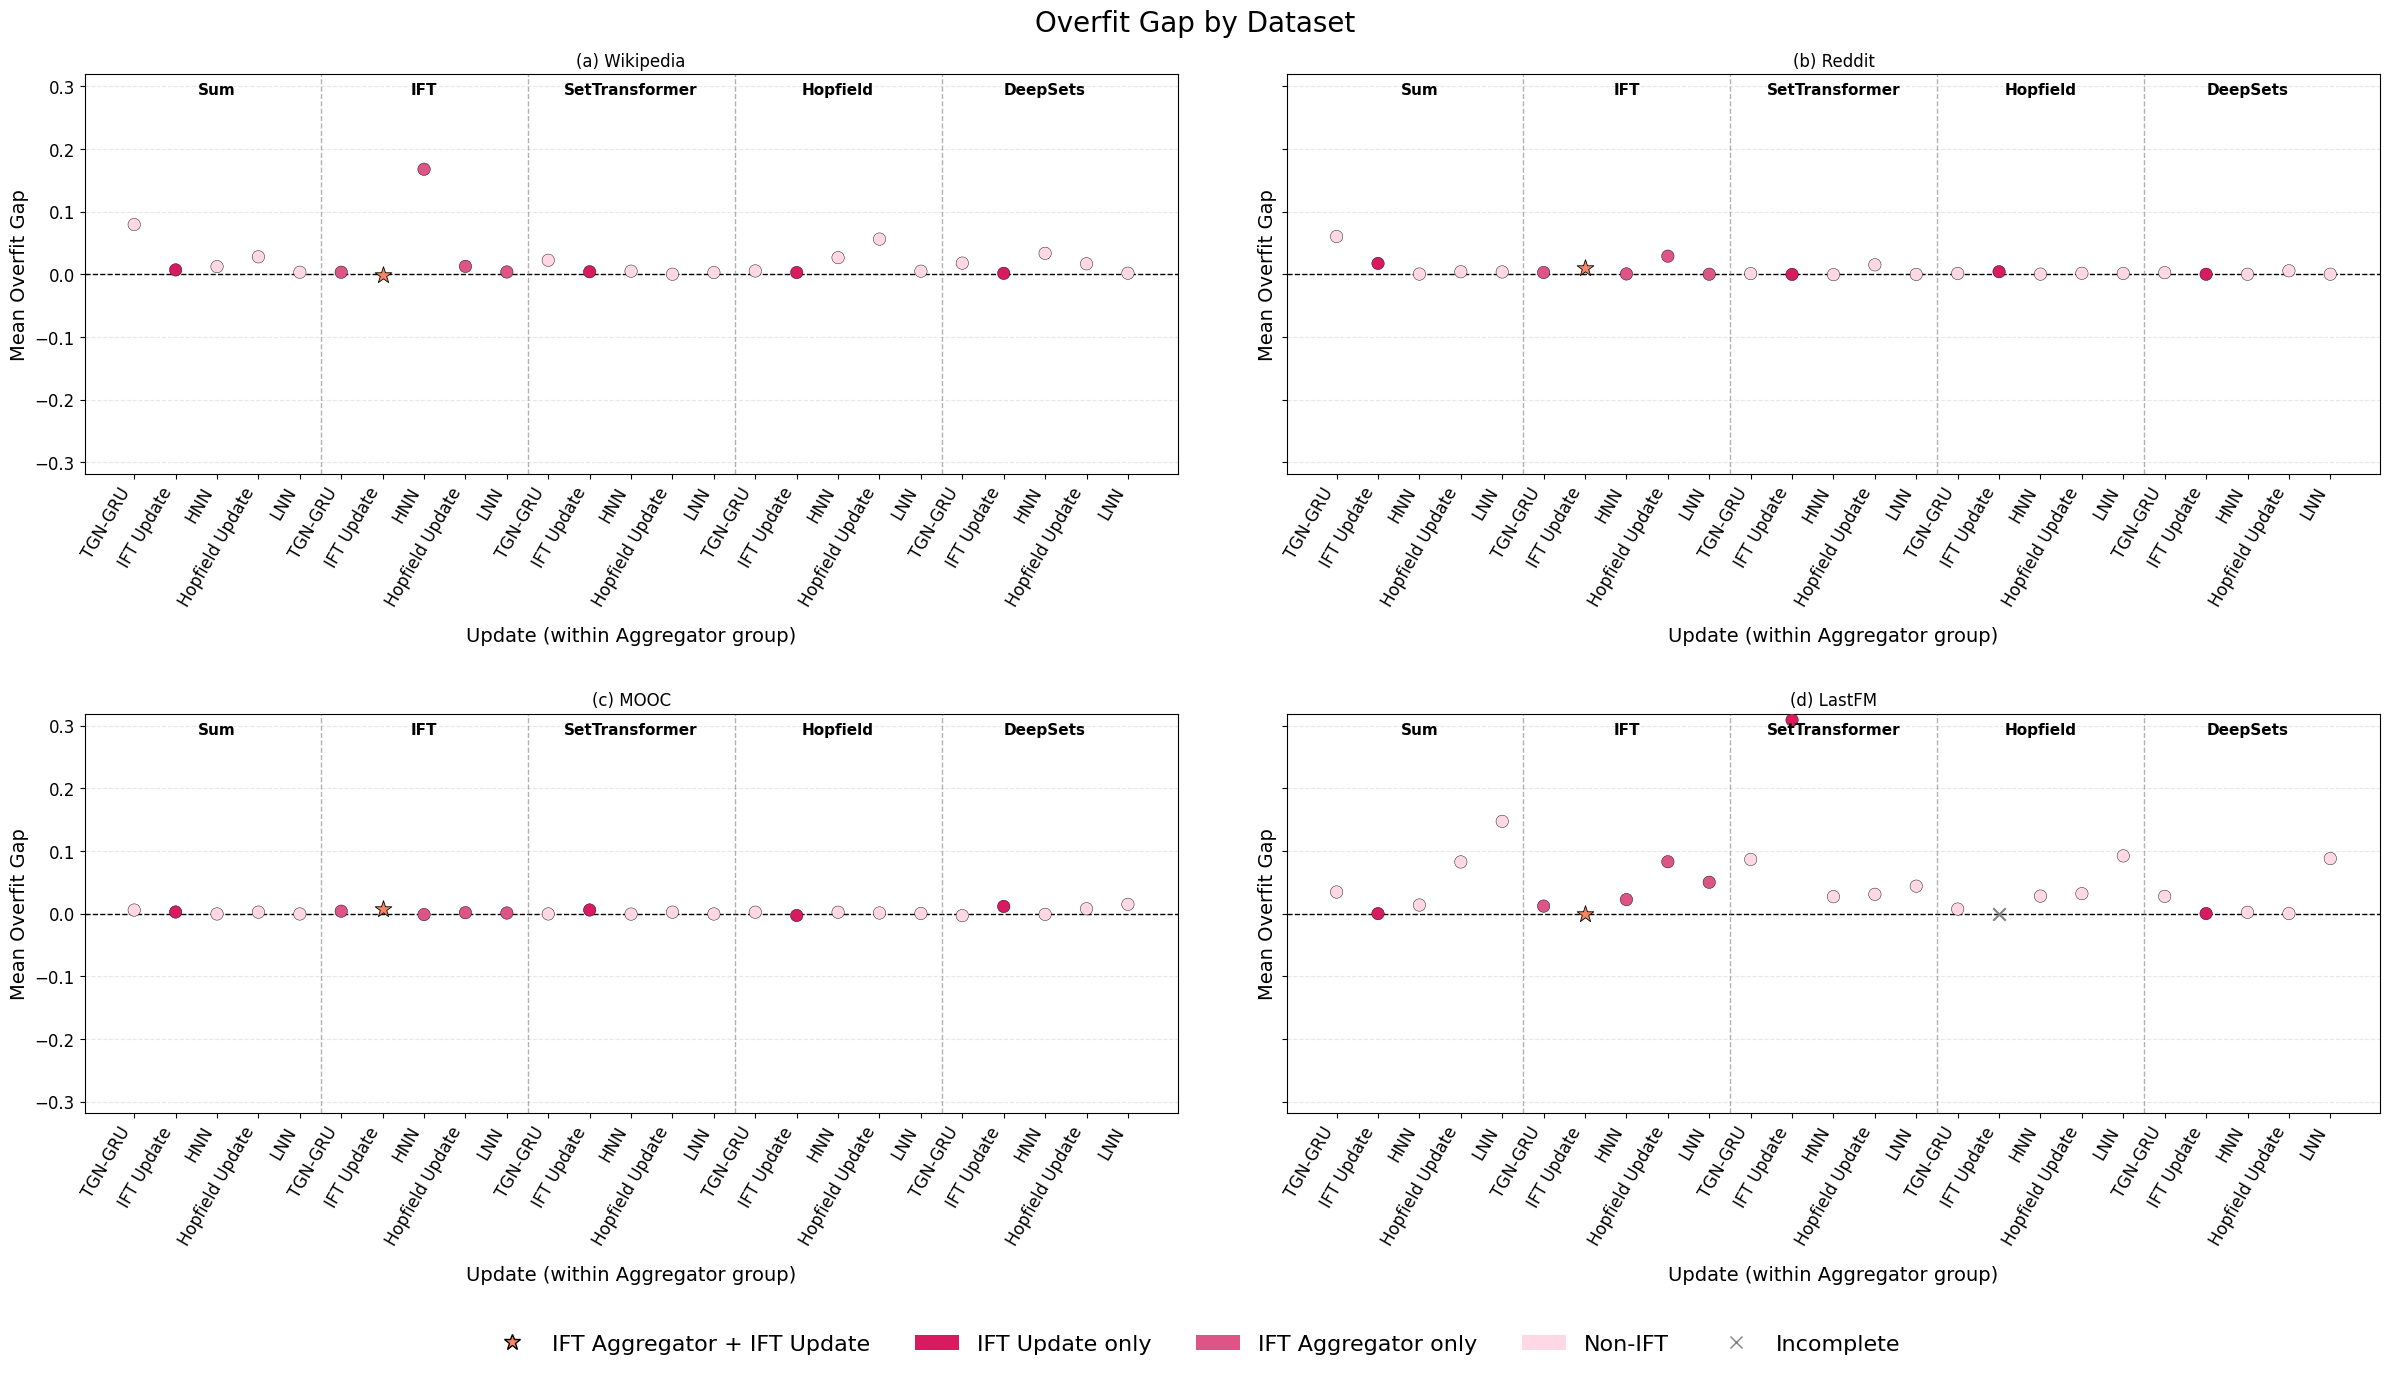

In [ ]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=True)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

absmax = np.nanmax(np.abs(plot_df["mean_overfit_gap"].values))
ymin, ymax = -absmax - 0.01, absmax + 0.01

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["mean_overfit_gap"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # plot completed points
    mask = pd.notna(y)
    # identify special combo
    is_star = (df_full["aggregator"] == "ift") & (df_full["update"] == "ift_update")
    is_star = is_star.values & mask

    # normal points
    normal_mask = mask & ~is_star

    ax.scatter(
        x[normal_mask],
        y[normal_mask],
        c=np.array(colors)[normal_mask],
        s=80,
        edgecolors="black",
        linewidth=0.3,
        marker="o",
        zorder=3
    )

    # ⭐ star points
    ax.scatter(
        x[is_star],
        y[is_star],
        c="#f88664",   # same highlight color
        s=160,         # bigger so it stands out
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # plot incomplete combos as gray X on the zero line
    incomplete_mask = ~mask
    if incomplete_mask.any():
        ax.scatter(
            x[incomplete_mask],
            np.zeros(incomplete_mask.sum()),
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    ax.axhline(0, linestyle="--", color="black", linewidth=1)
    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Mean Overfit Gap", fontsize=14)
    ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator headers above each block
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            ymax - 0.02 * (ymax - ymin),   # 👈 inside plot near top
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#f88664', markeredgecolor='black', markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray", linestyle="None", markersize=8, label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Overfit Gap by Dataset", fontsize=20, y=.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(
    hspace=0.6,   # vertical spacing between rows
    wspace=0.1    # horizontal spacing between columns
)
fig.savefig(PLOTS_DIR / "overfit_gap_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

KeyError: 'spring_ring_2d'

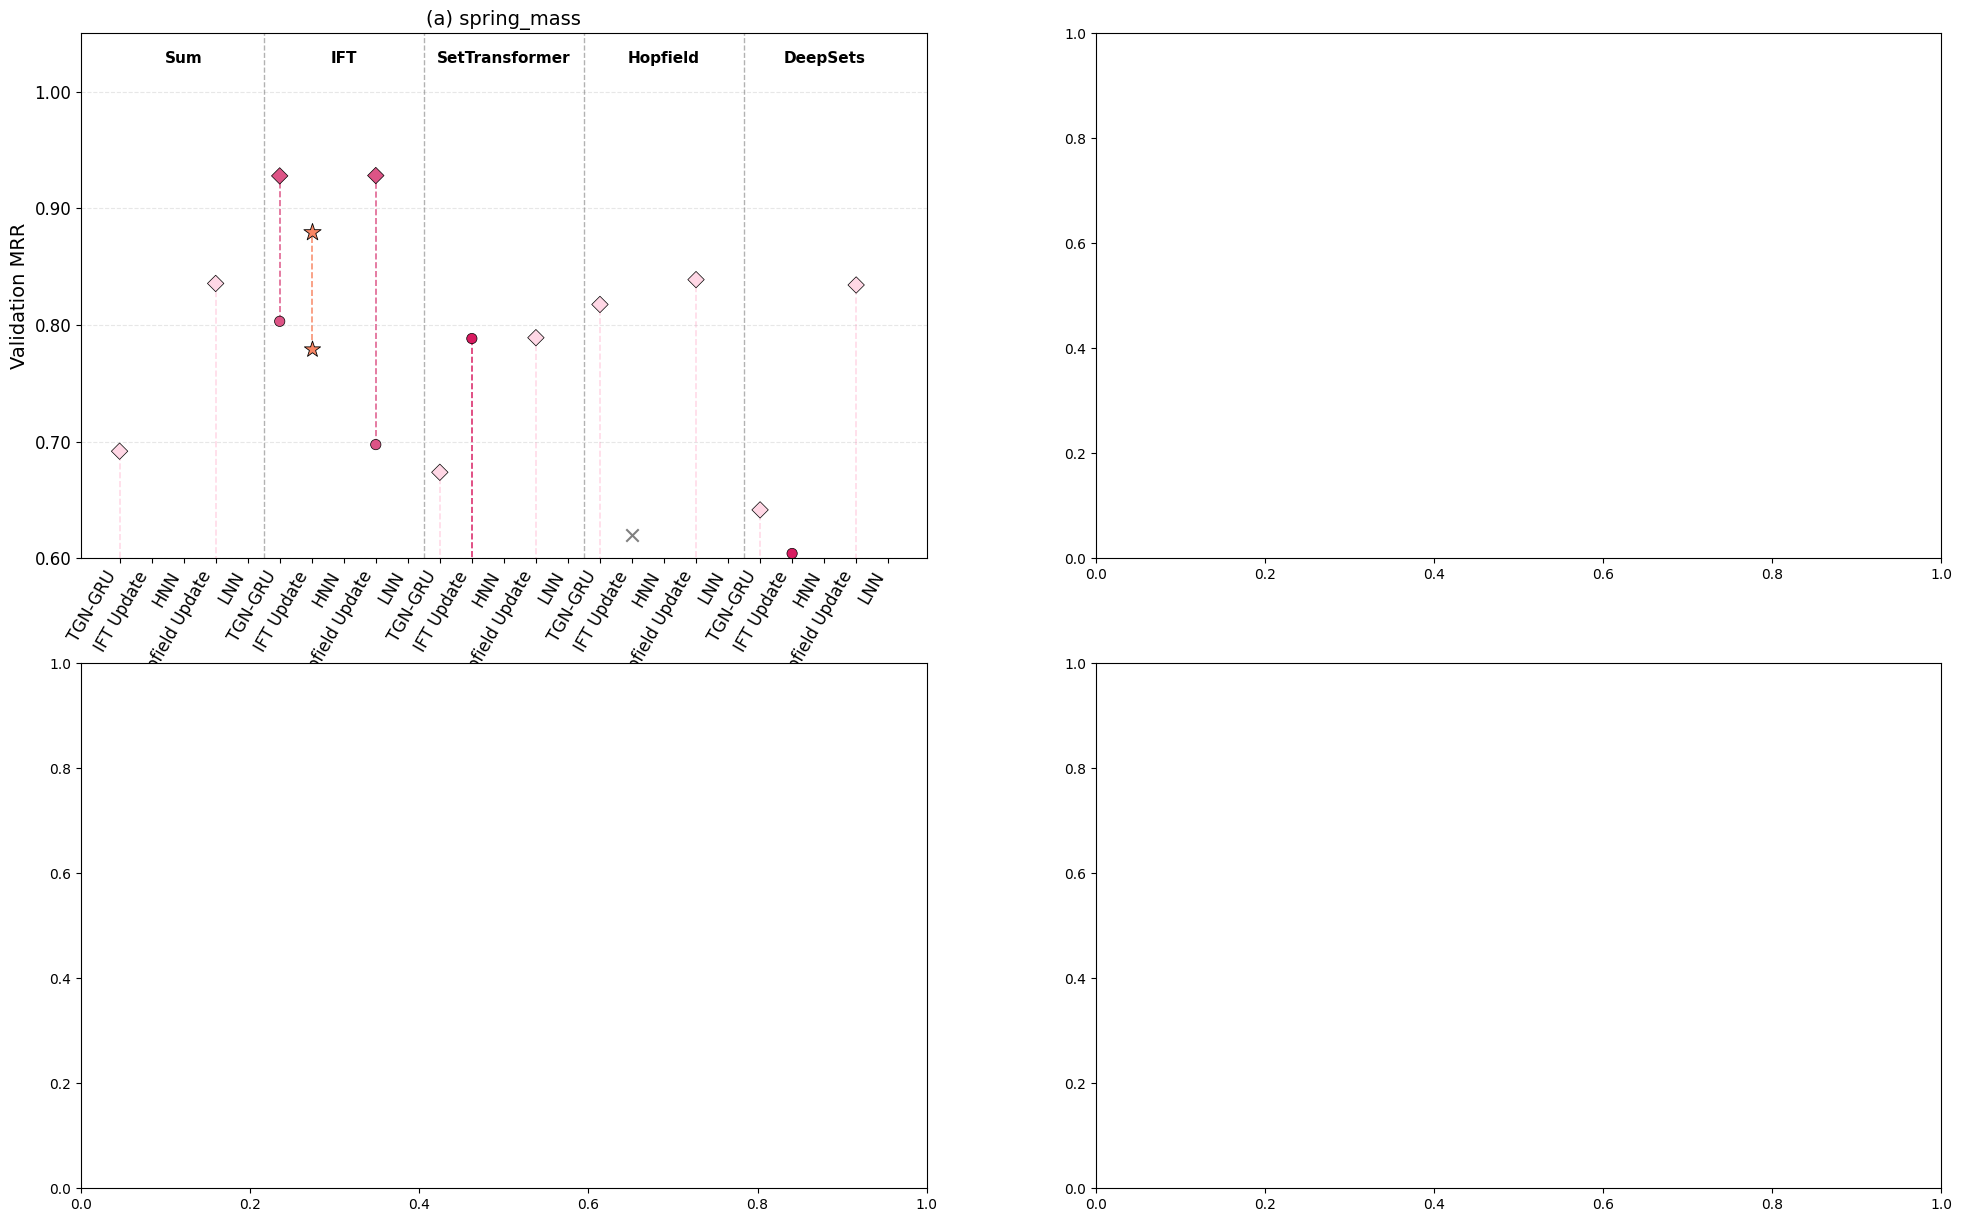

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=False)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    early = df_full["avg_early_val_mrr"].values
    late = df_full["avg_late_val_mrr"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    combo_colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # masks
    early_mask = pd.notna(early)
    late_mask = pd.notna(late)
    complete_mask = early_mask & late_mask

    is_star = (
        (df_full["aggregator"] == "ift") &
        (df_full["update"] == "ift_update")
    ).values

    normal_complete = complete_mask & ~is_star
    star_complete = complete_mask & is_star
    incomplete_mask = ~(early_mask & late_mask)

    # connector lines for complete combos only
    for i in np.where(complete_mask)[0]:
        ax.plot(
            [x[i], x[i]],
            [early[i], late[i]],
            color=combo_colors[i],
            linewidth=1.2,
            linestyle="--",
            alpha=0.9,
            zorder=1
        )

    # normal early points
    ax.scatter(
        x[normal_complete],
        early[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=55,
        edgecolors="black",
        linewidth=0.5,
        marker="o",
        zorder=3
    )

    # normal late points
    ax.scatter(
        x[normal_complete],
        late[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=70,
        edgecolors="black",
        linewidth=0.5,
        marker="D",
        zorder=3
    )

    # star combo early
    ax.scatter(
        x[star_complete],
        early[star_complete],
        c="#f88664",
        s=150,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # star combo late
    ax.scatter(
        x[star_complete],
        late[star_complete],
        c="#f88664",
        s=170,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # incomplete combos shown as gray X near bottom
    if incomplete_mask.any():
        y_incomplete = np.full(incomplete_mask.sum(), 0.62 if ds in ["spring_mass", "spring_ring", "wave", "nbody", "stachyose","threebody",] else 0.03)
        ax.scatter(
            x[incomplete_mask],
            y_incomplete,
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    # y axis range
    if ds in ["spring_mass", "spring_ring", "wave", "nbody", "stachyose","threebody",]:
        ax.set_ylim(0.6, 1.05)
        top_y = 1.035
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.08)
        top_y = 1.06

    ax.set_title(f"{panel_label} {ds}", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # only left column y-label
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel("Validation MRR", fontsize=14)
    else:
        ax.set_ylabel("")

    # only bottom row x-label
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    else:
        ax.set_xlabel("")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator labels inside plot
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            top_y,
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

# legends
model_color_legend = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor="#f88664", markeredgecolor="black",
           markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray",
           linestyle="None", markersize=8, label="Incomplete"),
]

phase_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Early Val"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Late Val"),
]

fig.legend(
    handles=model_color_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.legend(
    handles=phase_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=2,
    frameon=False,
    fontsize=16
)

fig.suptitle("Early vs Late Validation Performance", fontsize=20, y=0.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(hspace=0.6, wspace=0.1)

fig.savefig(PLOTS_DIR / "early_vs_late_val_dumbbell_grouped.png", dpi=300, bbox_inches="tight")
plt.show()